<a href="https://colab.research.google.com/github/anajulidorio/inteligencia-artificial/blob/main/algoritmosGeneticos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import random as rd
from random import randint
import matplotlib.pyplot as plt

In [ ]:
n = 10
numero_itens = np.arange(1 , n+1 )

pesos = [2.5, 1.8, 0.7, 2.1, 1.5, 2.2, 0.9, 1.6, 0.5, 1.1]

valores =[2000, 1450, 3400, 1900, 1300, 1000, 600, 1300, 400, 900]

nomes = ['SMARTPHONE SAMSUNG GALAXY S21',
         'NOTEBOOK DELL INSPIRON 15',
         'FONE DE OUVIDO BLUETOOTH JBL',
         'SMARTWATCH SAMSUNG GALAXY WATCH 3',
         'TABLET APPLE IPAD 10.2',
         'CÂMERA DIGITAL CANON EOS REBEL T7',
         'MOUSE GAMER LOGITECH G PRO',
         'TECLADO MECÂNICO REDRAGON KUMARA',
         'CAIXA DE SOM BLUETOOTH JBL GO',
         'SMARTBAND XIAOMI MI BAND 6']

max_peso_mochila = 7

In [ ]:
for i in range (numero_itens.shape[0]):
  print('Item: {} \nPeso(Kg): {} \nValor(R$): {} \n'.format(nomes[i], pesos[i], valores[i]))

Item: SMARTPHONE SAMSUNG GALAXY S21 
Peso(Kg): 2.5 
Valor(R$): 2000 

Item: NOTEBOOK DELL INSPIRON 15 
Peso(Kg): 1.8 
Valor(R$): 1450 

Item: FONE DE OUVIDO BLUETOOTH JBL 
Peso(Kg): 0.7 
Valor(R$): 3400 

Item: SMARTWATCH SAMSUNG GALAXY WATCH 3 
Peso(Kg): 2.1 
Valor(R$): 1900 

Item: TABLET APPLE IPAD 10.2 
Peso(Kg): 1.5 
Valor(R$): 1300 

Item: CÂMERA DIGITAL CANON EOS REBEL T7 
Peso(Kg): 2.2 
Valor(R$): 1000 

Item: MOUSE GAMER LOGITECH G PRO 
Peso(Kg): 0.9 
Valor(R$): 600 

Item: TECLADO MECÂNICO REDRAGON KUMARA 
Peso(Kg): 1.6 
Valor(R$): 1300 

Item: CAIXA DE SOM BLUETOOTH JBL GO 
Peso(Kg): 0.5 
Valor(R$): 400 

Item: SMARTBAND XIAOMI MI BAND 6 
Peso(Kg): 1.1 
Valor(R$): 900 



In [ ]:
#numero de soluções ou indivíduos por população
solucao_por_populacao = 8
tamanho_populacao = (solucao_por_populacao, numero_itens.shape[0])

print('Tamanho da população: {}'.format(tamanho_populacao))
print('Número de indivíduos (solução) = {}'.format(tamanho_populacao[0]))
print('Número itens (genes) = {}'.format(tamanho_populacao[1]))

Tamanho da população: (8, 10)
Número de indivíduos (solução) = 8
Número itens (genes) = 10


In [ ]:
n_geracoes = 10

# criando pop. onde apenas um item diferente será levado por cada indivíduo
populacao_inicial = np.eye(tamanho_populacao[0], tamanho_populacao[1], k=0)

populacao_inicial = populacao_inicial.astype(int)

print('População Inicial: \n{}'.format(populacao_inicial))

População Inicial: 
[[1 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 1 0 0]]


In [ ]:
# função para calcular o fitness de cada indivíduo
def cal_fitness(peso, valor, populacao, max_peso_mochila):
  fitness = np.zeros(populacao.shape[0])

  # percorre cada indivíduo
  for i in range(populacao.shape[0]):
    # multiplica os itens que o indivíduo ta levando pelo valor e a soma
    s1 = np.sum(populacao[i] * valor)

    # multiplica os itens pelo peso e soma
    s2 = np.sum(populacao[i] * peso)

    # verifica se o valor não ultrapassa a capacidade máxima
    if s2 <= max_peso_mochila:
      fitness[i] = s1
    else:
      fitness[i] = 0

  return fitness.astype(float)

In [ ]:
# função para seleção dos indivíduos
def selecao_roleta(fitness, numero_pais, populacao):

  # soma os fitness
  max_fitness = sum(fitness)

  # calcula a probabilidade de cada um
  probabilidades = fitness/max_fitness

  # realiza a seleção com base nas probabilidaes
  selecionados = populacao[np.random.choice(len(populacao),
                                            size = numero_pais,
                                            p = probabilidades)]
  return selecionados

In [ ]:
def crossover(pais, numero_filhos):
  filhos = np.zeros((numero_filhos, pais.shape[1]))

  ponto_crossover = int(pais.shape [1]/2)

  for k in range(numero_filhos):
        # Indice do primeiro a ser fatiado.
        pai_1_idx = k % pais.shape[0]
        # Indice do segundo a ser fatiado.
        pai_2_idx = (k + 1) % pais.shape[0]

        # A nova prole terá sua primeira metade de seus genes retirados do primeiro pai.
        filhos[k, 0:ponto_crossover] = pais[pai_1_idx, 0:ponto_crossover]
        # A nova prole terá sua segunda metade de seus genes retirados do segundo pai.
        filhos[k, ponto_crossover:] = pais[pai_2_idx, ponto_crossover:]

  return filhos

In [ ]:
def mutacao(filhos):
    # Cria um vetor para armazenar os indivíduos mutados
    mutacoes = filhos
    # Percorre todos os filhos
    for i in range(mutacoes.shape[0]):
        # Pega aleatoriamente (posição) um gene do filho
        posicao_gene = randint(0, filhos.shape[1]-1)
        # Se aquele gene é 0 muda pra 1
        if mutacoes[i, posicao_gene] == 0:
            mutacoes[i, posicao_gene] = 1
        else:
            mutacoes[i, posicao_gene] = 0

    return mutacoes

In [ ]:
def rodar_AG(pesos, valores, populacao, tamanho_populacao, n_geracoes, max_peso_mochila):
    # Criando variáveis para parametros, histórico de fitness
    historico_fitness, historico_populacao = [], []
    # Calculando o número de pais.
    numero_pais = int(tamanho_populacao[0]/2)
    # Calculando o número de filhos
    numero_filhos = tamanho_populacao[0] - numero_pais
    fitness = []

    # Repetição até o número de gerações setado
    for i in range(n_geracoes):
        print('--- Começando a Geração {} ---'.format(i))
        # Calcula o fitness (aptidão) de cada indivíduo
        fitness = cal_fitness(pesos, valores, populacao, max_peso_mochila)
        # Armazena na variável de histórico
        historico_fitness.append(fitness.copy())
        historico_populacao.append(populacao.copy())

        # Pais selecionados
        pais = selecao_roleta(fitness, numero_pais, populacao)
        # Gerando os filhos
        filhos = crossover(pais, numero_filhos)
        # Mutando os filhos
        filhos_mutados = mutacao(filhos)

        print('População Antiga:')
        print(populacao)

        populacao[0:pais.shape[0], :] = pais
        populacao[pais.shape[0]:, :] = filhos_mutados

        print('População Nova:')
        print(populacao)

    return historico_populacao, historico_fitness

In [ ]:
historico_populacao, historico_fitness = rodar_AG (pesos,
                                                   valores,
                                                   populacao_inicial,
                                                   tamanho_populacao,
                                                   n_geracoes,
                                                   max_peso_mochila)

--- Começando a Geração 0 ---
População Antiga:
[[1 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 1 0 0]]
População Nova:
[[0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 1 0 0]
 [0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0]
 [0 1 0 0 0 0 0 1 0 0]
 [0 0 0 1 0 0 0 0 0 0]
 [0 1 1 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]]
--- Começando a Geração 1 ---
População Antiga:
[[0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 1 0 0]
 [0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0]
 [0 1 0 0 0 0 0 1 0 0]
 [0 0 0 1 0 0 0 0 0 0]
 [0 1 1 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]]
População Nova:
[[0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0]
 [0 1 0 0 0 0 0 1 0 0]
 [0 1 1 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 1 1 0 0]
 [1 1 0 0 0 0 1 0 0 0]
 [0 1 1 0 0 0 0 1 0 0]]
--- Começando a Geração 2 ---
População Antiga:
[[0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0]
 [0 1 0 0 0 0 0 1 0 0]
 [0 1 1 0 0 0 1

In [ ]:
def cal_fitness(pesos, valores, populacao, max_peso_mochila):
    fitness = np.empty(populacao.shape[0])
    for i in range(populacao.shape[0]):
        soma_valor = np.sum(populacao[i] * valores)
        soma_peso = np.sum(populacao[i] * pesos)
        if soma_peso <= max_peso_mochila:
            fitness[i] = soma_valor
        else:
            fitness[i] = 0
    return fitness.astype(int)

In [ ]:
dataframe = pd.DataFrame(historico_fitness)

dataframe

,0,1,2,3,4,5,6,7
0,2000.0,1450.0,3400.0,1900.0,1300.0,1000.0,600.0,1300.0
1,1300.0,1300.0,3400.0,600.0,2750.0,1900.0,5450.0,0.0
2,3400.0,1300.0,2750.0,5450.0,1300.0,1900.0,4050.0,6150.0
3,2750.0,4050.0,6150.0,3400.0,5450.0,0.0,5250.0,5300.0
4,5250.0,3400.0,6150.0,5250.0,3400.0,5600.0,1850.0,6550.0
5,5600.0,5250.0,6150.0,5600.0,4800.0,7450.0,8350.0,7050.0
6,6150.0,7050.0,8350.0,8350.0,5750.0,0.0,7050.0,6000.0
7,6150.0,6000.0,7050.0,7050.0,8050.0,5600.0,6150.0,8050.0
8,8050.0,6150.0,7050.0,7050.0,0.0,8350.0,0.0,7150.0
9,7050.0,8350.0,8350.0,8050.0,0.0,0.0,6150.0,0.0


In [ ]:
max_index = dataframe.values.argmax()
linha, coluna = np.unravel_index(max_index, dataframe.shape)

print('Valor do fitness (Max): ', dataframe.iloc[linha, coluna])
print('Linha do maior fitness (Geração): ', linha)
print('Coluna do maior fitness (Indivíduo): ', coluna)

Valor do fitness (Max):  8350.0
Linha do maior fitness (Geração):  5
Coluna do maior fitness (Indivíduo):  6


In [ ]:
melhor_individuo = historico_populacao[linha][coluna]

In [ ]:
itens_selecionados = numero_itens * melhor_individuo
dataframe_itens = pd.DataFrame(columns=['Item', 'Valor', 'Peso'])

for i in itens_selecionados:
  if i != 0:
    posicao = i-1
    item = {'Item': nomes[posicao], 'Valor': valores[posicao], 'Peso': pesos[posicao]}
    dataframe_itens.loc[len(dataframe_itens)] = item

In [ ]:
dataframe_itens

,Item,Valor,Peso
0,NOTEBOOK DELL INSPIRON 15,1450,1.8
1,FONE DE OUVIDO BLUETOOTH JBL,3400,0.7
2,TABLET APPLE IPAD 10.2,1300,1.5
3,TECLADO MECÂNICO REDRAGON KUMARA,1300,1.6
4,SMARTBAND XIAOMI MI BAND 6,900,1.1


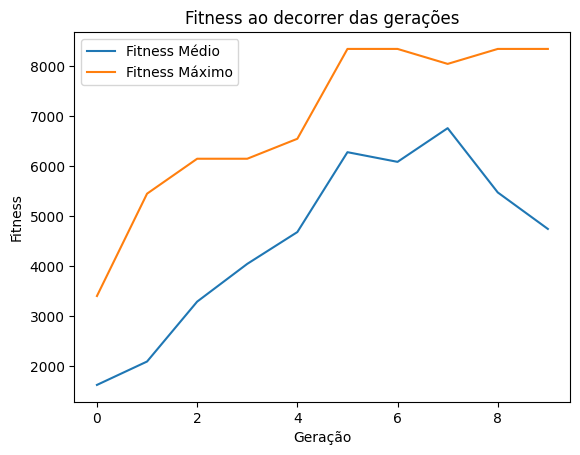

(10, 8)


In [ ]:
fitness_medio = [np.mean(fitness) for fitness in historico_fitness]
fitness_max = [np.max(fitness) for fitness in historico_fitness]

plt.plot(list(range(n_geracoes)), fitness_medio, label = 'Fitness Médio')
plt.plot(list(range(n_geracoes)), fitness_max, label = 'Fitness Máximo')
plt.legend()
plt.title('Fitness ao decorrer das gerações')
plt.xlabel('Geração')
plt.ylabel('Fitness')
plt.show()
print(np.asanyarray(historico_fitness).shape)